La CNN-1D es una buena candidata para cerrar la comparativa de modelos de deep learning del TFG.

Frente al MLP, puede capturar patrones locales entre variables consecutivas dentro de una ventana. Frente a la LSTM, suele ser mas ligera y mas facil de entrenar. En este notebook seguimos el mismo patron general: Optuna multiobjetivo con F1 y latencia, seleccion de candidatos desde la frontera de Pareto, evaluacion final en test y benchmark de recursos del modelo ganador.

In [2]:
import os
import time
import numpy as np
import polars as pl
import optuna
import psutil
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow import keras
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix, roc_curve, auc
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler

HAS_GPU = len(tf.config.list_physical_devices('GPU')) > 0
TRAIN_DEVICE = '/GPU:0' if HAS_GPU else '/CPU:0'
INFER_DEVICE = '/CPU:0'

if HAS_GPU:
    print('GPU detectada. El entrenamiento se ejecutara en GPU y la inferencia se medira en CPU.')
else:
    print('No hay GPU disponible. Entrenamiento e inferencia se ejecutaran en CPU.')

tf.keras.backend.clear_session()


/mnt/AI-DATA/placivm_tfg/PLACI_TFG/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
I0000 00:00:1774465013.215331 2541394 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1774465013.268492 2541394 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1774465015.808357 2541394 port.cc:153] oneDNN custom oper

GPU detectada. El entrenamiento se ejecutara en GPU y la inferencia se medira en CPU.


In [ ]:
DEFAULT_DROPOUT_RATE = 0.2

def build_cnn1d_model(n_features, n_filters, kernel_size, dense_units, dropout_rate=DEFAULT_DROPOUT_RATE):
    model = keras.Sequential([
        keras.layers.Input(shape=(n_features, 1)), # <-- Forma tabular (características como secuencia)
        keras.layers.Conv1D(filters=n_filters, kernel_size=kernel_size, padding='same', activation='relu'),
        keras.layers.MaxPooling1D(pool_size=2),
        keras.layers.Conv1D(filters=max(16, n_filters // 2), kernel_size=kernel_size, padding='same', activation='relu'),
        keras.layers.GlobalMaxPooling1D(),
        keras.layers.Dense(dense_units, activation='relu'),
        keras.layers.Dropout(dropout_rate),
        keras.layers.Dense(1, activation='sigmoid')
    ])

    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

def clone_model_to_cpu(trained_model, n_features, n_filters, kernel_size, dense_units, dropout_rate):
    with tf.device(INFER_DEVICE):
        cpu_model = build_cnn1d_model(
            n_features=n_features,
            n_filters=n_filters,
            kernel_size=kernel_size,
            dense_units=dense_units,
            dropout_rate=dropout_rate
        )
        cpu_model.set_weights(trained_model.get_weights())
    return cpu_model

# --- CARGA DEL DATASET UNSW-NB15 ---
path_train = '../DATASETS/dataSets_Reducidos/nusw-nb15/datos_train_NUSW_redux.csv'
path_test  = '../DATASETS/dataSets_Reducidos/nusw-nb15/datos_test_NUSW_redux.csv'

df_train = pl.read_csv(path_train)
df_test  = pl.read_csv(path_test)
TARGET_COL = 'attack_cat'

y_train = (
    df_train.select(
        pl.when(pl.col(TARGET_COL).str.strip_chars() == 'Normal')
        .then(1)
        .otherwise(-1)
        .alias('label')
    )
    .to_series()
    .cast(pl.Int8)
)

y_test = (
    df_test.select(
        pl.when(pl.col(TARGET_COL).str.strip_chars() == 'Normal')
        .then(1)
        .otherwise(-1)
        .alias('label')
    )
    .to_series()
    .cast(pl.Int8)
)

x_train = df_train.drop(TARGET_COL)
x_test = df_test.drop(TARGET_COL)

X_full_train = x_train.to_numpy()
y_full_train = y_train.to_numpy()
X_test_np = x_test.to_numpy()
y_test_np = y_test.to_numpy()

# Convertimos de {-1, 1} a {0, 1} para la entropía cruzada binaria
y_full_train_01 = ((y_full_train + 1) // 2).astype(np.int8)
y_test_np01 = ((y_test_np + 1) // 2).astype(np.int8)

X_train_np, X_val_np, y_train_np, y_val_np = train_test_split(
    X_full_train,
    y_full_train,
    test_size=0.2,
    random_state=42,
    stratify=y_full_train
)

print(f'Forma de X_full_train: {X_full_train.shape}')
print(f'Forma de X_test: {X_test_np.shape}')
print('Distribución de clases en train:')
print(y_train.value_counts())
print('Distribución de clases en test:')
print(y_test.value_counts())
print('\nNota metodológica: La CNN-1D procesa cada flujo de forma independiente como un vector tabular, utilizando las características extraídas para encontrar correlaciones locales.')

Forma de X_full_train: (175341, 12)
Forma de X_test: (82332, 12)
Distribucion de clases en train:
shape: (2, 2)
┌───────┬────────┐
│ label ┆ count  │
│ ---   ┆ ---    │
│ i8    ┆ u32    │
╞═══════╪════════╡
│ 1     ┆ 56000  │
│ -1    ┆ 119341 │
└───────┴────────┘
Distribucion de clases en test:
shape: (2, 2)
┌───────┬───────┐
│ label ┆ count │
│ ---   ┆ ---   │
│ i8    ┆ u32   │
╞═══════╪═══════╡
│ 1     ┆ 37000 │
│ -1    ┆ 45332 │
└───────┴───────┘

Nota metodologica: igual que en LSTM, la CNN-1D trabaja con ventanas deslizantes sobre filas consecutivas del dataset reducido. Conviene presentarla como comparativa exploratoria de deep learning, no como modelo secuencial plenamente temporal.


In [ ]:
# ==========================================
# 2. OPTUNA MULTIOBJETIVO: F1 Y LATENCIA
# ==========================================

def objective(trial):
    tf.keras.backend.clear_session()

    n_filters = trial.suggest_int('n_filters', 32, 128, step=32)
    kernel_size = trial.suggest_int('kernel_size', 2, 5) # Valores clásicos para tabular
    dense_units = trial.suggest_int('dense_units', 16, 96, step=16)
    
    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    f1_scores = []
    inference_times = []

    for train_idx, val_idx in skf.split(X_full_train, y_full_train_01):
        X_train_fold = X_full_train[train_idx]
        y_train_fold = y_full_train_01[train_idx]
        X_val_fold = X_full_train[val_idx]
        y_val_fold = y_full_train_01[val_idx]

        # 1. Escalado Min-Max
        scaler = MinMaxScaler()
        X_train_fold_scaled = scaler.fit_transform(X_train_fold)
        X_val_fold_scaled = scaler.transform(X_val_fold)

        # 2. Reshape Tabular a 3D para la Conv1D (muestras, features, canales)
        X_train_cnn = X_train_fold_scaled.reshape(X_train_fold_scaled.shape[0], X_train_fold_scaled.shape[1], 1)
        X_val_cnn = X_val_fold_scaled.reshape(X_val_fold_scaled.shape[0], X_val_fold_scaled.shape[1], 1)
        
        n_features = X_train_cnn.shape[1]

        with tf.device(TRAIN_DEVICE):
            model = build_cnn1d_model(
                n_features=n_features,
                n_filters=n_filters,
                kernel_size=kernel_size,
                dense_units=dense_units,
                dropout_rate=DEFAULT_DROPOUT_RATE
            )

            early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
            model.fit(
                X_train_cnn,
                y_train_fold,
                validation_split=0.1,
                epochs=20,
                batch_size=1024,
                callbacks=[early_stop],
                verbose=0
            )

        cpu_model = clone_model_to_cpu(
            trained_model=model,
            n_features=n_features,
            n_filters=n_filters,
            kernel_size=kernel_size,
            dense_units=dense_units,
            dropout_rate=DEFAULT_DROPOUT_RATE
        )

        with tf.device(INFER_DEVICE):
            y_pred_prob = cpu_model.predict(X_val_cnn, batch_size=1024, verbose=0).ravel()

        y_pred = (y_pred_prob > 0.5).astype(np.int8)
        f1_scores.append(f1_score(y_val_fold, y_pred, average='binary', zero_division=0))

        X_lat = X_val_cnn[:min(20000, len(X_val_cnn))]
        if len(X_lat) == 0:
            continue

        with tf.device(INFER_DEVICE):
            _ = cpu_model.predict(X_lat[:min(512, len(X_lat))], batch_size=512, verbose=0)

        rep_lat = []
        for _ in range(3):
            with tf.device(INFER_DEVICE):
                t0 = time.perf_counter()
                _ = cpu_model.predict(X_lat, batch_size=1024, verbose=0)
                t1 = time.perf_counter()
            rep_lat.append((t1 - t0) / len(X_lat))

        inference_times.append(float(np.mean(rep_lat)))

        tf.keras.backend.clear_session()

    return float(np.mean(f1_scores)), float(np.mean(inference_times))

study = optuna.create_study(directions=['maximize', 'minimize'], study_name='cnn1d_unsw_optimization')
print('Iniciando barrido multiobjetivo con CNN-1D (entrenamiento en GPU, inferencia medida en CPU)...')
study.optimize(objective, n_trials=25, show_progress_bar=True)

results = []
pareto_trials = {trial.number for trial in study.best_trials}
for trial in study.trials:
    if trial.values is None:
        continue

    row = {
        'Trial': trial.number,
        'F1_CV': float(trial.values[0]),
        'Latencia_ms': float(trial.values[1] * 1000),
        'Pareto': trial.number in pareto_trials
    }
    row.update(trial.params)
    results.append(row)

df_cnn_trials = pl.DataFrame(results).sort(['Pareto', 'F1_CV', 'Latencia_ms'], descending=[True, True, False])
df_cnn_trials.write_csv('cnn1d_unsw_trials_results_cv.csv')
print("\nResultados guardados en 'cnn1d_unsw_trials_results_cv.csv'")
print(df_cnn_trials)

[I 2026-03-24 23:37:32,714] A new study created in memory with name: cnn1d_ids_optimization


Iniciando barrido multiobjetivo con CNN-1D (entrenamiento en GPU si existe, inferencia medida en CPU)...


  0%|          | 0/25 [00:00<?, ?it/s]I0000 00:00:1774391853.523817  210561 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 43054 MB memory:  -> device: 0, name: NVIDIA L40S, pci bus id: 0000:4a:00.0, compute capability: 8.9
I0000 00:00:1774391853.524965  210561 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 43054 MB memory:  -> device: 1, name: NVIDIA L40S, pci bus id: 0000:61:00.0, compute capability: 8.9
I0000 00:00:1774391853.526325  210561 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:2 with 43054 MB memory:  -> device: 2, name: NVIDIA L40S, pci bus id: 0000:ca:00.0, compute capability: 8.9
I0000 00:00:1774391853.527389  210561 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:3 with 43054 MB memory:  -> device: 3, name: NVIDIA L40S, pci bus id: 0000:e1:00.0, compute capability: 8.9
I0000 00:00:1774391858.100995  211185 service.cc:153] XLA service 

[I 2026-03-24 23:38:22,319] Trial 0 finished with values: [0.9246812123653142, 9.135601369457112e-06] and parameters: {'time_steps': 13, 'n_filters': 96, 'kernel_size': 4, 'dense_units': 96}.


I0000 00:00:1774391903.805619  211185 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_26018__.21
I0000 00:00:1774391903.851853  211185 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1774391904.541622  211185 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1774391907.835760  211185 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_26018__.21
I0000 00:00:1774391907.883592  211185 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a g

...

[I 2026-03-24 23:49:54,947] Trial 22 finished with values: [0.9129619498477531, 7.889355853613881e-06] and parameters: {'time_steps': 8, 'n_filters': 32, 'kernel_size': 3, 'dense_units': 96}.


I0000 00:00:1774392596.871811  211186 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_539154__.21
I0000 00:00:1774392597.042261  211186 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1774392597.722779  211186 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1774392600.234761  211187 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_539154__.21
I0000 00:00:1774392600.351432  211187 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a

[I 2026-03-24 23:50:25,601] Trial 23 finished with values: [0.9045100682360512, 7.666486656914154e-06] and parameters: {'time_steps': 5, 'n_filters': 64, 'kernel_size': 2, 'dense_units': 16}.


I0000 00:00:1774392627.586455  211185 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_560785__.21
I0000 00:00:1774392627.890442  211185 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1774392628.453227  211185 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1774392628.733948  560578 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_14', 12 bytes spill stores, 12 bytes spill loads

I0000 00:00:1774392631.423645  211185 dot_merger.cc:481] Merging Dots in computation: a_inference_one_st

[I 2026-03-24 23:51:00,784] Trial 24 finished with values: [0.9231736299665662, 9.101027177853717e-06] and parameters: {'time_steps': 11, 'n_filters': 96, 'kernel_size': 5, 'dense_units': 64}.

Resultados guardados en 'cnn1d_trials_results_cv.csv'
shape: (25, 8)
┌───────┬──────────┬─────────────┬────────┬────────────┬───────────┬─────────────┬─────────────┐
│ Trial ┆ F1_CV    ┆ Latencia_ms ┆ Pareto ┆ time_steps ┆ n_filters ┆ kernel_size ┆ dense_units │
│ ---   ┆ ---      ┆ ---         ┆ ---    ┆ ---        ┆ ---       ┆ ---         ┆ ---         │
│ i64   ┆ f64      ┆ f64         ┆ bool   ┆ i64        ┆ i64       ┆ i64         ┆ i64         │
╞═══════╪══════════╪═════════════╪════════╪════════════╪═══════════╪═════════════╪═════════════╡
│ 19    ┆ 0.926714 ┆ 0.009155    ┆ true   ┆ 15         ┆ 96        ┆ 3           ┆ 32          │
│ 18    ┆ 0.924973 ┆ 0.008837    ┆ true   ┆ 12         ┆ 96        ┆ 3           ┆ 80          │
│ 9     ┆ 0.92387  ┆ 0.008637    ┆ true   ┆ 15         ┆ 3

Trial,F1_CV,Latencia_ms,Pareto,time_steps,n_filters,kernel_size,dense_units
i64,f64,f64,bool,i64,i64,i64,i64
23,0.90451,0.007666,true,5,64,2,16
11,0.907492,0.007769,true,6,64,2,64
22,0.912962,0.007889,true,8,32,3,96
1,0.91409,0.008009,true,7,64,2,48
7,0.916184,0.008333,true,9,64,3,64
5,0.918049,0.008587,true,7,64,4,80
9,0.92387,0.008637,true,15,32,4,96
18,0.924973,0.008837,true,12,96,3,80
19,0.926714,0.009155,true,15,96,3,32


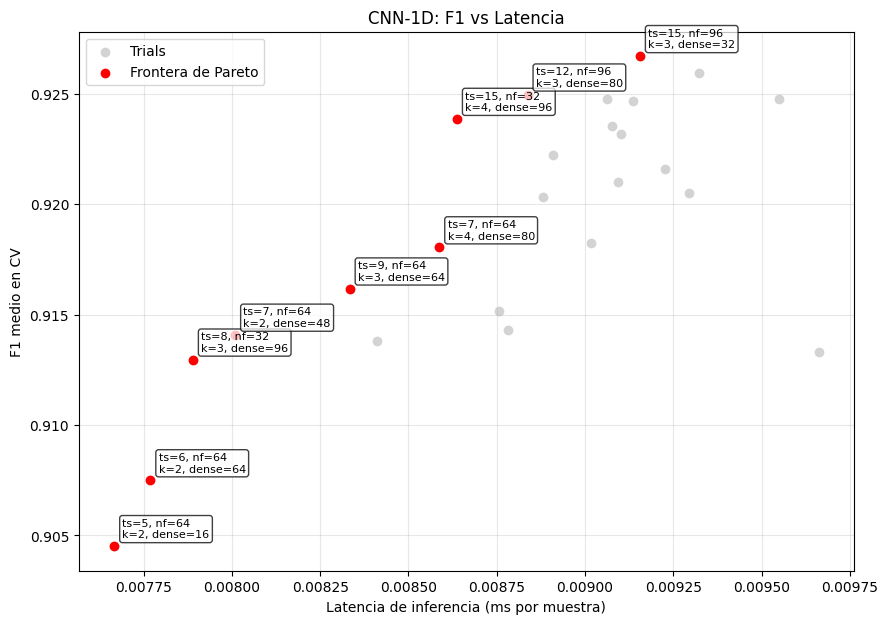

In [4]:
import polars as pl
import matplotlib.pyplot as plt

# Leer resultados desde el CSV
df_cnn_trials = pl.read_csv("cnn1d_trials_results_cv.csv")

# Filtrar frontera de Pareto
df_pareto = (
    df_cnn_trials
    .filter(pl.col("Pareto") == True)
    .sort("Latencia_ms")
)

display(df_pareto)

plt.figure(figsize=(10, 7))

plt.scatter(
    df_cnn_trials["Latencia_ms"],
    df_cnn_trials["F1_CV"],
    c="lightgray",
    label="Trials"
)

plt.scatter(
    df_pareto["Latencia_ms"],
    df_pareto["F1_CV"],
    c="red",
    label="Frontera de Pareto"
)

# Mostrar hiperparámetros de los puntos Pareto
for row in df_pareto.iter_rows(named=True):
    texto = (
        f"ts={row['time_steps']}, nf={row['n_filters']}\n"
        f"k={row['kernel_size']}, dense={row['dense_units']}"
    )
    plt.annotate(
        texto,
        (row["Latencia_ms"], row["F1_CV"]),
        textcoords="offset points",
        xytext=(6, 6),
        ha="left",
        fontsize=8,
        bbox=dict(boxstyle="round,pad=0.25", fc="white", alpha=0.75)
    )

plt.xlabel("Latencia de inferencia (ms por muestra)")
plt.ylabel("F1 medio en CV")
plt.title("CNN-1D: F1 vs Latencia")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [5]:
# ==========================================
# 4. EVALUACION FINAL EN TEST (CNN-1D)
# ==========================================

candidatos = [
    {'ts': 15, 'nf': 96, 'k': 3, 'd': 32, 'nombre': 'Candidato 1'},
    {'ts': 12, 'nf': 96, 'k': 3, 'd': 80, 'nombre': 'Candidato 2'},
    {'ts': 15, 'nf': 32, 'k': 4, 'd': 96, 'nombre': 'Candidato 3'},
    {'ts': 7, 'nf': 64, 'k': 4, 'd': 80, 'nombre': 'Candidato 4'},
    {'ts': 9, 'nf': 64, 'k': 3, 'd': 64, 'nombre': 'Candidato 5'},
]

resultados_finales = []

print('--- EVALUACION FINAL SOBRE EL SET DE TEST (CNN-1D) ---\n')

for c in candidatos:
    tf.keras.backend.clear_session()
    print(
        f"Probando {c['nombre']}: TS={c['ts']}, Filtros={c['nf']}, "
        f"Kernel={c['k']}, Dense={c['d']}"
    )

    time_steps = int(c['ts'])
    n_filters = int(c['nf'])
    kernel_size = int(c['k'])
    dense_units = int(c['d'])

    scaler = StandardScaler()
    X_full_train_scaled = scaler.fit_transform(X_full_train)
    X_test_scaled = scaler.transform(X_test_np)

    X_train_seq, y_train_seq = create_sequences(X_full_train_scaled, y_full_train_01, time_steps)
    X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test_np01, time_steps)

    with tf.device(TRAIN_DEVICE):
        model = build_cnn1d_model(
            time_steps=time_steps,
            n_features=X_train_seq.shape[2],
            n_filters=n_filters,
            kernel_size=kernel_size,
            dense_units=dense_units,
            dropout_rate=DEFAULT_DROPOUT_RATE
        )

        early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
        model.fit(
            X_train_seq,
            y_train_seq,
            validation_split=0.1,
            epochs=20,
            batch_size=1024,
            callbacks=[early_stop],
            verbose=0
        )

    cpu_model = clone_model_to_cpu(
        trained_model=model,
        time_steps=time_steps,
        n_features=X_train_seq.shape[2],
        n_filters=n_filters,
        kernel_size=kernel_size,
        dense_units=dense_units,
        dropout_rate=DEFAULT_DROPOUT_RATE
    )

    with tf.device(INFER_DEVICE):
        y_prob = cpu_model.predict(X_test_seq, batch_size=1024, verbose=0).ravel()
    y_pred = (y_prob > 0.5).astype(np.int8)

    X_lat = X_test_seq[:min(20000, len(X_test_seq))]
    if len(X_lat) == 0:
        raise ValueError('No hay suficientes muestras en test para medir latencia con la configuracion seleccionada.')

    with tf.device(INFER_DEVICE):
        _ = cpu_model.predict(X_lat[:min(512, len(X_lat))], batch_size=512, verbose=0)

    rep_lat = []
    for _ in range(3):
        with tf.device(INFER_DEVICE):
            t0 = time.perf_counter()
            _ = cpu_model.predict(X_lat, batch_size=1024, verbose=0)
            t1 = time.perf_counter()
        rep_lat.append((t1 - t0) / len(X_lat))

    f1_test = float(f1_score(y_test_seq, y_pred, zero_division=0))
    acc_test = float(accuracy_score(y_test_seq, y_pred))
    lat_ms = float(np.mean(rep_lat) * 1000)

    resultados_finales.append({
        'Perfil': c['nombre'],
        'time_steps': time_steps,
        'n_filters': n_filters,
        'kernel_size': kernel_size,
        'dense_units': dense_units,
        'F1_Test': f1_test,
        'Accuracy_Test': acc_test,
        'Latencia_ms': lat_ms
    })
    print(f"  -> F1={f1_test:.4f} | Acc={acc_test:.4f} | Latencia={lat_ms:.6f} ms")

df_candidate_results = pl.DataFrame(resultados_finales).sort(['F1_Test', 'Latencia_ms'], descending=[True, False])

print('\n' + '=' * 88)
print('              TABLA COMPARATIVA FINAL (CNN-1D - TEST SET)')
print('=' * 88)
print(df_candidate_results)

# Puedes cambiar manualmente esta eleccion si prefieres otro candidato.
best_c = candidatos[0]
print('\nModelo ganador seleccionado para ROC, matriz de confusion y benchmark:')
print(best_c)


--- EVALUACION FINAL SOBRE EL SET DE TEST (CNN-1D) ---

Probando Candidato 1: TS=15, Filtros=96, Kernel=3, Dense=32


I0000 00:00:1774465044.389412 2541394 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 43487 MB memory:  -> device: 0, name: NVIDIA L40S, pci bus id: 0000:4a:00.0, compute capability: 8.9
I0000 00:00:1774465044.390556 2541394 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 43487 MB memory:  -> device: 1, name: NVIDIA L40S, pci bus id: 0000:61:00.0, compute capability: 8.9
I0000 00:00:1774465044.391913 2541394 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:2 with 43487 MB memory:  -> device: 2, name: NVIDIA L40S, pci bus id: 0000:ca:00.0, compute capability: 8.9
I0000 00:00:1774465044.392978 2541394 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:3 with 43487 MB memory:  -> device: 3, name: NVIDIA L40S, pci bus id: 0000:e1:00.0, compute capability: 8.9
I0000 00:00:1774465046.349447 2546717 service.cc:153] XLA service 0x7f31a4032190 initialized for platfor

  -> F1=0.9193 | Acc=0.9326 | Latencia=0.009589 ms
Probando Candidato 2: TS=12, Filtros=96, Kernel=3, Dense=80


I0000 00:00:1774465063.574536 2546717 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_13613__.21
I0000 00:00:1774465063.623408 2546717 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1774465064.081227 2546717 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1774465064.828977 2546717 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1774465068.09985

  -> F1=0.9056 | Acc=0.9218 | Latencia=0.009613 ms
Probando Candidato 3: TS=15, Filtros=32, Kernel=4, Dense=96


...

  -> F1=0.9077 | Acc=0.9236 | Latencia=0.009057 ms
Probando Candidato 4: TS=7, Filtros=64, Kernel=4, Dense=80


I0000 00:00:1774465092.357760 2546717 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_32030__.21
I0000 00:00:1774465092.500291 2546717 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1774465095.922030 2546717 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_32030__.21
I0000 00:00:1774465095.977542 2546717 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1774465096.549514 2546717 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a g

  -> F1=0.8975 | Acc=0.9151 | Latencia=0.008658 ms
Probando Candidato 5: TS=9, Filtros=64, Kernel=3, Dense=64


I0000 00:00:1774465106.761267 2546716 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_40879__.21
I0000 00:00:1774465107.037408 2546716 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1774465110.365318 2546716 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_40879__.21
I0000 00:00:1774465110.411662 2546716 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1774465110.972884 2546716 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a g

  -> F1=0.8925 | Acc=0.9121 | Latencia=0.008549 ms

              TABLA COMPARATIVA FINAL (CNN-1D - TEST SET)
shape: (5, 8)
┌────────────┬────────────┬───────────┬────────────┬────────────┬──────────┬───────────┬───────────┐
│ Perfil     ┆ time_steps ┆ n_filters ┆ kernel_siz ┆ dense_unit ┆ F1_Test  ┆ Accuracy_ ┆ Latencia_ │
│ ---        ┆ ---        ┆ ---       ┆ e          ┆ s          ┆ ---      ┆ Test      ┆ ms        │
│ str        ┆ i64        ┆ i64       ┆ ---        ┆ ---        ┆ f64      ┆ ---       ┆ ---       │
│            ┆            ┆           ┆ i64        ┆ i64        ┆          ┆ f64       ┆ f64       │
╞════════════╪════════════╪═══════════╪════════════╪════════════╪══════════╪═══════════╪═══════════╡
│ Candidato  ┆ 15         ┆ 96        ┆ 3          ┆ 32         ┆ 0.919338 ┆ 0.932591  ┆ 0.009589  │
│ 1          ┆            ┆           ┆            ┆            ┆          ┆           ┆           │
│ Candidato  ┆ 15         ┆ 32        ┆ 4          ┆ 96         ┆ 0.

In [ ]:
# ==========================================
# 5. ROC, MATRIZ DE CONFUSION Y BENCHMARK FINAL
# ==========================================

tf.keras.backend.clear_session()

time_steps = int(best_c['ts'])
n_filters = int(best_c['nf'])
kernel_size = int(best_c['k'])
dense_units = int(best_c['d'])
scaler_best = StandardScaler()
X_full_train_scaled = scaler_best.fit_transform(X_full_train)
X_test_scaled = scaler_best.transform(X_test_np)

X_train_seq, y_train_seq = create_sequences(X_full_train_scaled, y_full_train_01, time_steps)
X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test_np01, time_steps)

with tf.device(TRAIN_DEVICE):
    model_final = build_cnn1d_model(
        time_steps=time_steps,
        n_features=X_train_seq.shape[2],
        n_filters=n_filters,
        kernel_size=kernel_size,
        dense_units=dense_units,
        dropout_rate=DEFAULT_DROPOUT_RATE
    )

    early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
    model_final.fit(
        X_train_seq,
        y_train_seq,
        validation_split=0.1,
        epochs=20,
        batch_size=1024,
        callbacks=[early_stop],
        verbose=0
    )

model_final_cpu = clone_model_to_cpu(
    trained_model=model_final,
    time_steps=time_steps,
    n_features=X_train_seq.shape[2],
    n_filters=n_filters,
    kernel_size=kernel_size,
    dense_units=dense_units,
    dropout_rate=DEFAULT_DROPOUT_RATE
)

# ==========================================
# 5.1 BENCHMARK DE RECURSOS COMPUTACIONALES
# ==========================================
print('Midiendo recursos computacionales del modelo ganador (CNN-1D)...')
proceso = psutil.Process(os.getpid())
block_size = 2048
repetitions = 3

with tf.device(INFER_DEVICE):
    _ = model_final_cpu.predict(X_test_seq[:min(512, len(X_test_seq))], batch_size=512, verbose=0)

tiempos_muro = []
tiempos_cpu = []
picos_ram = []

for _ in range(repetitions):
    cpu_ini = proceso.cpu_times()
    ram_base = proceso.memory_info().rss / (1024 * 1024)
    pico_ram_rep = ram_base

    t0 = time.perf_counter()
    for inicio in range(0, len(X_test_seq), block_size):
        fin = inicio + block_size
        bloque = X_test_seq[inicio:fin]
        with tf.device(INFER_DEVICE):
            _ = model_final_cpu.predict(bloque, batch_size=512, verbose=0)

        ram_actual = proceso.memory_info().rss / (1024 * 1024)
        if ram_actual > pico_ram_rep:
            pico_ram_rep = ram_actual

    t1 = time.perf_counter()
    cpu_fin = proceso.cpu_times()

    tiempos_muro.append(t1 - t0)
    tiempos_cpu.append((cpu_fin.user - cpu_ini.user) + (cpu_fin.system - cpu_ini.system))
    picos_ram.append(pico_ram_rep - ram_base)

media_muro = float(np.mean(tiempos_muro))
media_cpu = float(np.mean(tiempos_cpu))
pico_max_ram = float(np.max(picos_ram))
total_nucleos = psutil.cpu_count(logical=True)

df_benchmark_cnn1d = pl.DataFrame([{
    'Modelo': 'CNN-1D',
    'Latencia_ms': round((media_muro / len(X_test_seq)) * 1000, 5),
    'Thruput (paq/s)': round(len(X_test_seq) / media_muro, 0),
    'Nucleos CPU': round(media_cpu / media_muro if media_muro > 0 else 1, 1),
    'Pico RAM (MB)': round(pico_max_ram, 2),
    'Porcentaje CPU': round(((media_cpu / media_muro) / total_nucleos) * 100 if media_muro > 0 else 0, 1)
}])
print(df_benchmark_cnn1d)

# ==========================================
# 5.2 PREDICCIONES Y GRAFICAS
# ==========================================
with tf.device(INFER_DEVICE):
    y_pred_prob = model_final_cpu.predict(X_test_seq, batch_size=1024, verbose=0).ravel()
y_pred = (y_pred_prob > 0.5).astype(np.int8)

cm = confusion_matrix(y_test_seq, y_pred)
fpr, tpr, _ = roc_curve(y_test_seq, y_pred_prob)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=ax[0],
    xticklabels=['Ataque (0)', 'Normal (1)'],
    yticklabels=['Ataque (0)', 'Normal (1)']
)
ax[0].set_title('Matriz de Confusion - CNN-1D')
ax[0].set_xlabel('Prediccion')
ax[0].set_ylabel('Realidad')

ax[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (AUC = {roc_auc:.4f})')
ax[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Clasificador aleatorio')
ax[1].set_xlim([0.0, 1.0])
ax[1].set_ylim([0.0, 1.05])
ax[1].set_xlabel('Tasa de Falsos Positivos (FPR)')
ax[1].set_ylabel('Tasa de Verdaderos Positivos (TPR)')
ax[1].set_title('Curva ROC - CNN-1D')
ax[1].legend(loc='lower right')
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()
